# Notebook entregable para el reclutamiento de Data Acquisition de UNAM Motorsport

En esta segunda etapa de trabajo, he dado una estructura un poco más rigida a la notebook, con el objetivo de tener más orden

In [10]:
#Requesitos de la NB
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

In [2]:
# 1. Cargamos el dataset 
df = pd.read_csv('data.csv')

# 2. Visualizamos las primeras 5 filas para entender la estructura de los datos
print("--- Primeras 5 filas del dataset ---")
display(df.head())

# 3. Revisar información general: nombres de columnas, tipos de datos y conteo de nulos
print("\n--- Información del dataset ---")
df.info()

--- Primeras 5 filas del dataset ---


,Timestamp,speed_kmph,accel_x,accel_y,brake_pressure,steering_angle,throttle,lane_deviation,phone_usage,headway_distance,reaction_time,behavior_label
0,0.00,36.075011,0.535763,0.708633,23.107812,-3.169956,53.123505,0.851871,1,17.996005,1.400050,Distracted
1,0.01,38.090536,0.973764,0.044312,36.961137,-24.380082,36.383904,1.459495,1,29.904182,1.428537,Distracted
2,0.02,71.314445,1.000000,0.789375,79.734087,-6.100238,78.110507,0.254723,0,11.126012,0.406950,Aggressive
3,0.03,86.485997,1.000000,0.221966,45.007002,17.886191,82.794935,0.911664,0,11.064505,0.539964,Aggressive
4,0.04,52.816777,-0.201763,0.560619,38.759612,-4.104323,61.432375,1.591244,1,21.967570,1.369908,Distracted



--- Información del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Timestamp         30000 non-null  float64
 1   speed_kmph        30000 non-null  float64
 2   accel_x           30000 non-null  float64
 3   accel_y           30000 non-null  float64
 4   brake_pressure    30000 non-null  float64
 5   steering_angle    30000 non-null  float64
 6   throttle          30000 non-null  float64
 7   lane_deviation    30000 non-null  float64
 8   phone_usage       30000 non-null  int64  
 9   headway_distance  30000 non-null  float64
 10  reaction_time     30000 non-null  float64
 11  behavior_label    30000 non-null  object 
dtypes: float64(10), int64(1), object(1)
memory usage: 2.7+ MB


Nos quedamos solo con lo que necesitamos

In [5]:
# 1. Definir solo las columnas críticas para el análisis dinámico y de seguridad
columnas_utiles = ['Timestamp', 'accel_x', 'accel_y', 'brake_pressure', 'throttle']

# 2. Cargar el dataset optimizando la memoria
print("--- CARGANDO TELEMETRÍA ---")
df_filtrado = df.loc[:, columnas_utiles]

# 3. Validar la huella de memoria
df_filtrado.info()

--- CARGANDO TELEMETRÍA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       30000 non-null  float64
 1   accel_x         30000 non-null  float64
 2   accel_y         30000 non-null  float64
 3   brake_pressure  30000 non-null  float64
 4   throttle        30000 non-null  float64
dtypes: float64(5)
memory usage: 1.1 MB


In [ ]:
print("--- INICIANDO DIAGNÓSTICO DE DATOS CRUDOS (MÉTODO DINÁMICO) ---\n")

# ==========================================
# 1. SATURACIÓN DE SEÑAL (Límites Dinámicos)
# ==========================================
# El código investiga cuáles son las cotas superiores e inferiores reales
max_x, min_x = df['accel_x'].max(), df['accel_x'].min()
max_y, min_y = df['accel_y'].max(), df['accel_y'].min()

# Contamos cuántas muestras chocan contra esos límites exactos 
# (usamos una tolerancia de 1e-4 por cómo Python maneja los decimales flotantes)
sat_x = df[(df['accel_x'] >= max_x - 1e-4) | (df['accel_x'] <= min_x + 1e-4)]
sat_y = df[(df['accel_y'] >= max_y - 1e-4) | (df['accel_y'] <= min_y + 1e-4)]

print(f"[1] SATURACIÓN X: Límites detectados [{min_x:.4f}G, {max_x:.4f}G] -> {len(sat_x)} muestras saturadas.")
print(f"[1] SATURACIÓN Y: Límites detectados [{min_y:.4f}G, {max_y:.4f}G] -> {len(sat_y)} muestras saturadas.\n")


# ==========================================
# 2. PÉRDIDAS DE SEÑAL (Saltos en el Timestamp)
# ==========================================
df_filtrado['delta_t'] = df_filtrado['Timestamp'].diff()
saltos_reloj = df_filtrado[abs(df_filtrado['delta_t'] - 0.01) > 0.0001]

if saltos_reloj.empty:
    print("[2] RELOJ: Muestreo continuo a 100 Hz. No hay saltos de tiempo.\n")
else:
    print(f"[2] RELOJ: ¡Alerta! {len(saltos_reloj)} saltos de tiempo detectados.\n")


# ==========================================
# 3. SEÑALES CONGELADAS (Sensores trabados)
# ==========================================
congelados_x = df_filtrado[df_filtrado['accel_x'].diff() == 0.0]
if congelados_x.empty:
    print("[3] CONGELAMIENTO: La señal inercial fluye correctamente.\n")
else:
    print(f"[3] CONGELAMIENTO: Se detectaron {len(congelados_x)} instantes donde la señal X se trabó.\n")


# ==========================================
# 4. FALLAS DE PLAUSIBILIDAD (Umbrales Investigados)
# ==========================================
# Calculamos el rango total de movimiento de cada pedal
rango_freno = df_filtrado['brake_pressure'].max() - df_filtrado['brake_pressure'].min()
rango_acel = df_filtrado['throttle'].max() - df_filtrado['throttle'].min()

# Definimos el "cero" como su valor mínimo real, más un pequeño margen (ej. 5%) por ruido eléctrico
umbral_freno_dinamico = df_filtrado['brake_pressure'].min() + (rango_freno * 0.05)
umbral_acel_dinamico = df_filtrado['throttle'].min() + (rango_acel * 0.05)

df_filtrado['falla_instantanea'] = (df_filtrado['brake_pressure'] > umbral_freno_dinamico) & (df_filtrado['throttle'] > umbral_acel_dinamico)

df_filtrado['grupo_racha'] = (df_filtrado['falla_instantanea'] != df_filtrado['falla_instantanea'].shift()).cumsum()
duracion_rachas = df_filtrado[df_filtrado['falla_instantanea']].groupby('grupo_racha').size()

# Filtramos rachas mayores a 10 muestras (>100 ms)
fallas_confirmadas = duracion_rachas[duracion_rachas > 10].index

if len(fallas_confirmadas) == 0:
    print("[4] PLAUSIBILIDAD: Ningún evento simultáneo superó los 100 ms continuos.")
else:
    print(f"[4] PLAUSIBILIDAD: ¡Se detectaron {len(fallas_confirmadas)} eventos reales (>100ms)!")
    for grupo in fallas_confirmadas:
        evento = df_filtrado[df_filtrado['grupo_racha'] == grupo]
        print(f"    -> Falla en T = {evento['Timestamp'].iloc[0]:.2f} s (Duración: {len(evento) * 10} ms)")

--- INICIANDO DIAGNÓSTICO DE DATOS CRUDOS (MÉTODO DINÁMICO) ---

[1] SATURACIÓN X: Límites detectados [-0.9496G, 1.0000G] -> 12757 muestras saturadas.
[1] SATURACIÓN Y: Límites detectados [-1.5326G, 2.7908G] -> 2 muestras saturadas.

[2] RELOJ: Muestreo continuo a 100 Hz. No hay saltos de tiempo.

[3] CONGELAMIENTO: Se detectaron 5605 instantes donde la señal X se trabó.

[4] PLAUSIBILIDAD: ¡Se detectaron 932 eventos reales (>100ms)!
    -> Falla en T = 0.18 s (Duración: 150 ms)
    -> Falla en T = 0.69 s (Duración: 130 ms)
    -> Falla en T = 1.07 s (Duración: 390 ms)
    -> Falla en T = 1.50 s (Duración: 140 ms)
    -> Falla en T = 1.65 s (Duración: 250 ms)
    -> Falla en T = 1.91 s (Duración: 130 ms)
    -> Falla en T = 2.34 s (Duración: 260 ms)
    -> Falla en T = 2.61 s (Duración: 190 ms)
    -> Falla en T = 2.94 s (Duración: 120 ms)
    -> Falla en T = 3.10 s (Duración: 370 ms)
    -> Falla en T = 3.48 s (Duración: 280 ms)
    -> Falla en T = 3.83 s (Duración: 140 ms)
    -> Fal

En los datos crudos encontramos una cantidad masiva de anomalías, principalmente la saturación del sensor de aceleración en el eje X.

Tendremos que reportarlo e indagar más causas probables, en el lado del evento de plausibilidad en datos crudos aún falta hacer exploración, pero dado a que los datos crudos presentan estas anomalías, aplicaremos el filtrado para obtener más información del sistemas

In [9]:
print("--- APLICANDO ACONDICIONAMIENTO DE SEÑAL ---")

# 1. Configuración del filtro Butterworth Pasa-Bajas
fs = 100.0       # Frecuencia de muestreo (100 Hz)
fc = 5.0         # Frecuencia de corte (5 Hz para dinámica de chasis)
nyq = 0.5 * fs   # Frecuencia de Nyquist (50 Hz)
orden = 4        # Orden del filtro

# 2. Obtener coeficientes
b, a = butter(orden, fc / nyq, btype='low')

# 3. Aplicar filtro filtfilt (fase cero) creando nuevas columnas
df_filtrado['accel_x_filt'] = filtfilt(b, a, df_filtrado['accel_x'])
df_filtrado['accel_y_filt'] = filtfilt(b, a, df_filtrado['accel_y'])

# 4. Calcular la Magnitud del Vector de Fuerza G Combinada
df_filtrado['G_combinada'] = np.sqrt(df_filtrado['accel_x_filt']**2 + df_filtrado['accel_y_filt']**2)

g_max = df_filtrado['G_combinada'].max()
print(f"Fuerza G combinada máxima detectada (señal limpia): {g_max:.4f} G")
print("Nota: Este valor está subestimado debido a la saturación artificial de 1G en el sensor X.")

--- APLICANDO ACONDICIONAMIENTO DE SEÑAL ---
Fuerza G combinada máxima detectada (señal limpia): 1.2720 G
Nota: Este valor está subestimado debido a la saturación artificial de 1G en el sensor X.


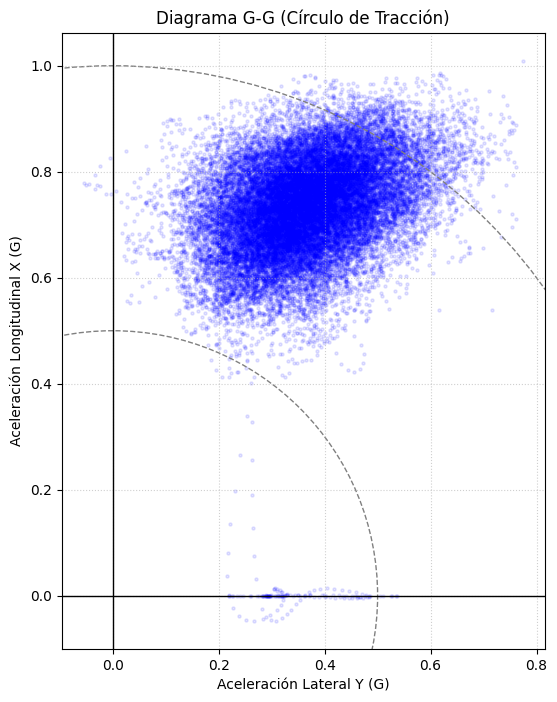

In [11]:
# Crear el lienzo
plt.figure(figsize=(8, 8))

# Graficar Lateral (Y) en el eje X del plot, y Longitudinal (X) en el eje Y del plot
plt.scatter(df_filtrado['accel_y_filt'], df_filtrado['accel_x_filt'], alpha=0.1, color='blue', s=5)

# Líneas de referencia y diseño
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Círculos de referencia visual (0.5G y 1.0G)
circle1 = plt.Circle((0, 0), 0.5, color='gray', fill=False, linestyle='--')
circle2 = plt.Circle((0, 0), 1.0, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle1)
plt.gca().add_artist(circle2)

# Etiquetas
plt.title('Diagrama G-G (Círculo de Tracción)')
plt.xlabel('Aceleración Lateral Y (G)')
plt.ylabel('Aceleración Longitudinal X (G)')

# Bloquear la proporción para que sea un cuadrado perfecto
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle=':', alpha=0.6)

# Mostrar gráfica
plt.show()

Con esto el código de la Notebook termina, la huella tiene características interesantes, el siguiente paso es el análisis de datos, para encontrar causas a los resultados